In [2]:
!rm -rf predictive-maintenance-cmapss
!git clone https://github.com/MaissaBM2003/predictive-maintenance-cmapss.git
import sys
sys.path.append("predictive-maintenance-cmapss")

Cloning into 'predictive-maintenance-cmapss'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 37 (delta 4), reused 34 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 187.64 KiB | 3.03 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [3]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_cmapss

with open("predictive-maintenance-cmapss/configs/config.yaml") as f:
    config = yaml.safe_load(f)

DATA_DIR = "/kaggle/input/datasets/maissabenmrad/nasa-cmaps/CMaps"
train, test, rul = load_cmapss(DATA_DIR, config["data"]["dataset"])

train.info()
print(train.isnull().sum().sum(), "valeurs manquantes")
train.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   op_1    20631 non-null  float64
 3   op_2    20631 non-null  float64
 4   op_3    20631 non-null  float64
 5   s_1     20631 non-null  float64
 6   s_2     20631 non-null  float64
 7   s_3     20631 non-null  float64
 8   s_4     20631 non-null  float64
 9   s_5     20631 non-null  float64
 10  s_6     20631 non-null  float64
 11  s_7     20631 non-null  float64
 12  s_8     20631 non-null  float64
 13  s_9     20631 non-null  float64
 14  s_10    20631 non-null  float64
 15  s_11    20631 non-null  float64
 16  s_12    20631 non-null  float64
 17  s_13    20631 non-null  float64
 18  s_14    20631 non-null  float64
 19  s_15    20631 non-null  float64
 20  s_16    20631 non-null  float64
 21  s_17    20631 non-null  int64  
 22

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
s_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
s_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


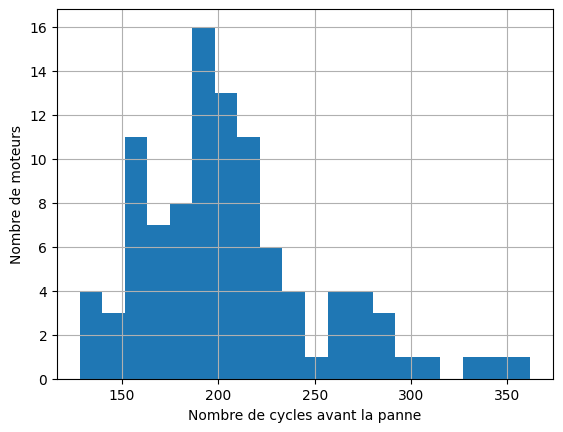

In [4]:
lifetimes = train.groupby("unit")["cycle"].max()
print(lifetimes.describe())

lifetimes.hist(bins=20)
plt.xlabel("Nombre de cycles avant la panne")
plt.ylabel("Nombre de moteurs")
plt.show()

In [5]:
features = [c for c in train.columns if c.startswith(("op_", "s_"))]
std = train[features].std().sort_values()
print(std)

op_3    0.000000e+00
s_19    0.000000e+00
s_18    0.000000e+00
s_16    1.556432e-14
s_10    4.660829e-13
s_5     3.394700e-12
s_1     6.537152e-11
op_2    2.930621e-04
s_6     1.388985e-03
op_1    2.187313e-03
s_15    3.750504e-02
s_8     7.098548e-02
s_13    7.191892e-02
s_21    1.082509e-01
s_20    1.807464e-01
s_11    2.670874e-01
s_2     5.000533e-01
s_12    7.375534e-01
s_7     8.850923e-01
s_17    1.548763e+00
s_3     6.131150e+00
s_4     9.000605e+00
s_14    1.907618e+01
s_9     2.208288e+01
dtype: float64


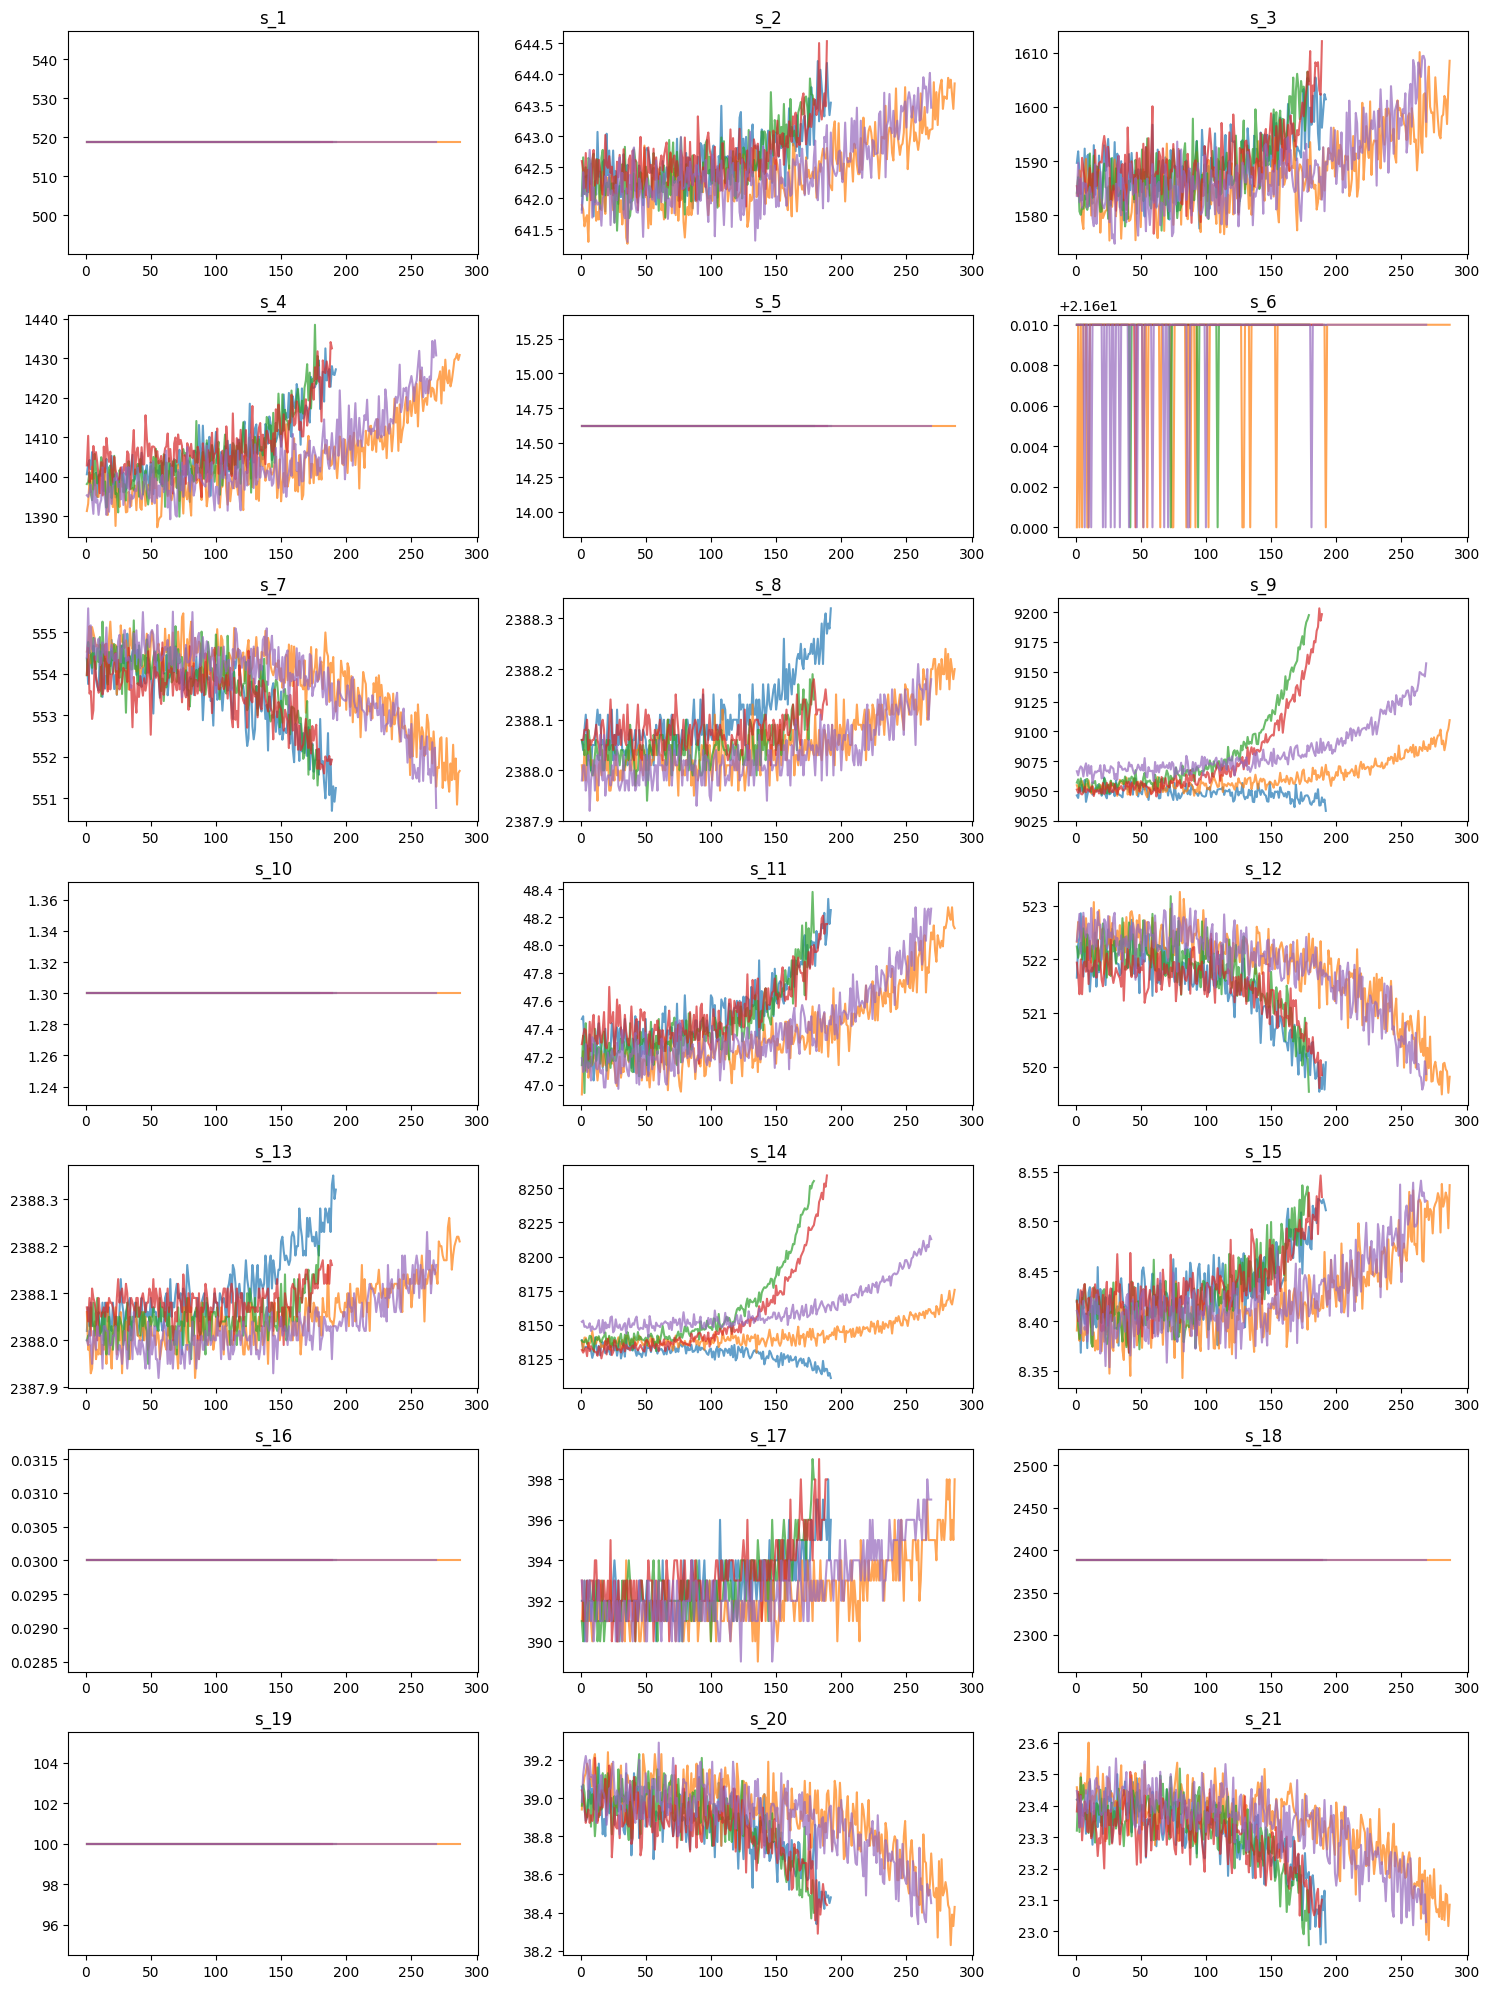

In [6]:
sensors = [f"s_{i}" for i in range(1, 22)]
units = train["unit"].unique()[:5]

fig, axes = plt.subplots(7, 3, figsize=(15, 20))
for ax, s in zip(axes.flat, sensors):
    for u in units:
        d = train[train["unit"] == u]
        ax.plot(d["cycle"], d[s], alpha=0.7)
    ax.set_title(s)
plt.tight_layout()
plt.show()

In [8]:
max_cycle = train.groupby("unit")["cycle"].transform("max")
train["rul"] = max_cycle - train["cycle"]

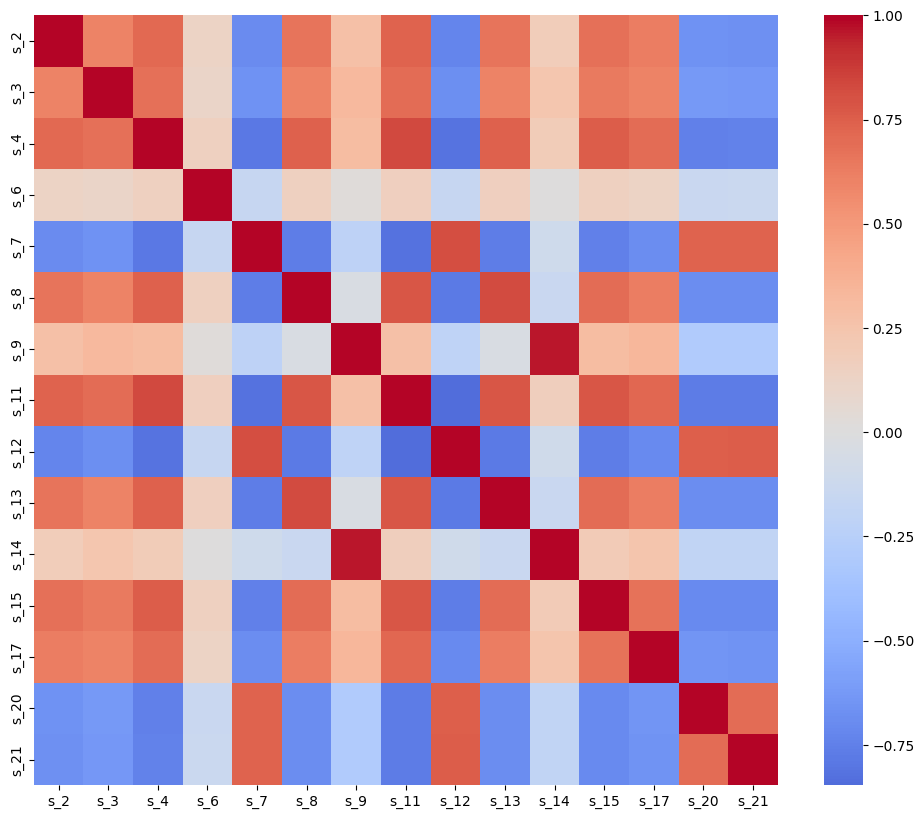

In [9]:
useful = [s for s in sensors if train[s].std() > 1e-3]
plt.figure(figsize=(12, 10))
sns.heatmap(train[useful].corr(), cmap="coolwarm", center=0, annot=False)
plt.show()

In [10]:
print(train[useful + ["rul"]].corr()["rul"].drop("rul").sort_values())

s_11   -0.696228
s_4    -0.678948
s_15   -0.642667
s_2    -0.606484
s_17   -0.606154
s_3    -0.584520
s_8    -0.563968
s_13   -0.562569
s_9    -0.390102
s_14   -0.306769
s_6    -0.128348
s_20    0.629428
s_21    0.635662
s_7     0.657223
s_12    0.671983
Name: rul, dtype: float64


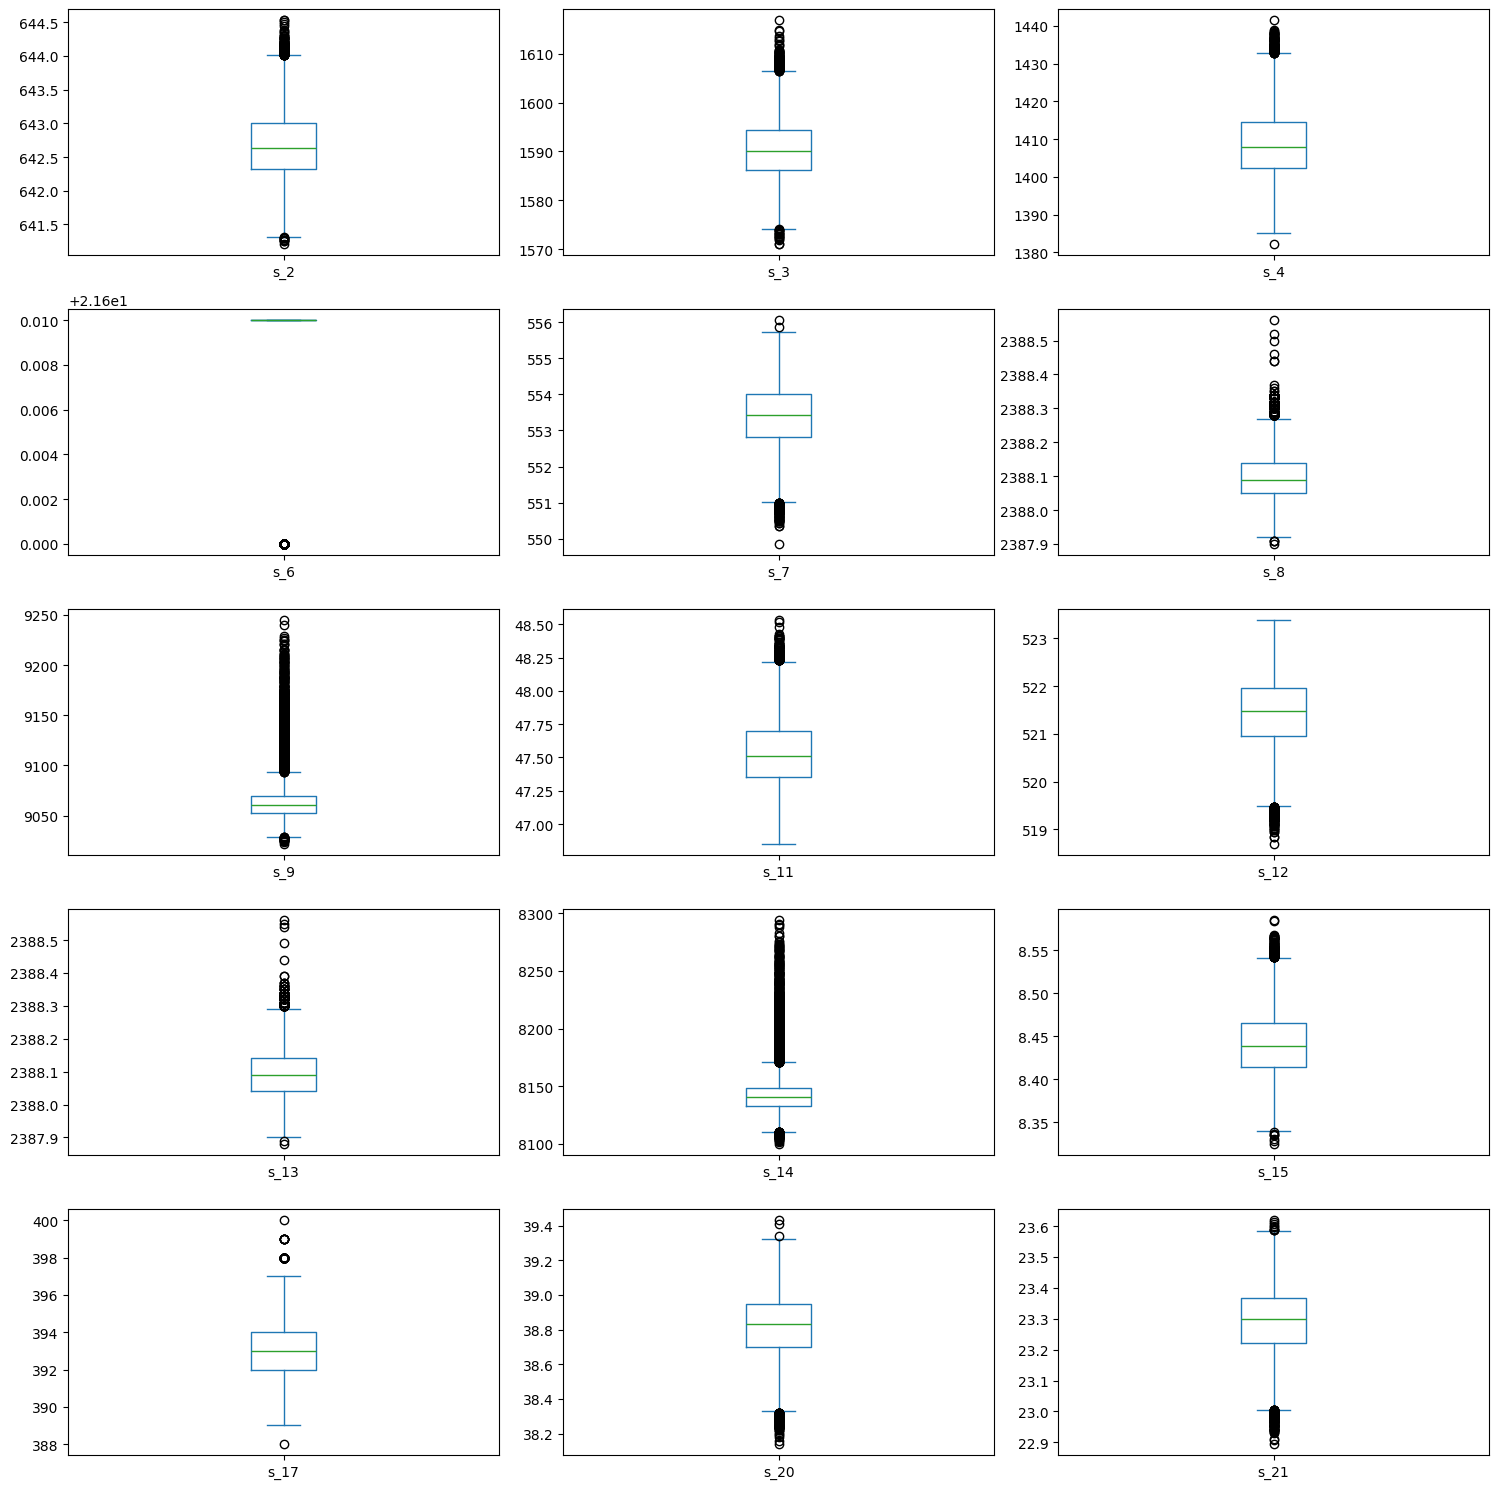

In [11]:
train[useful].plot(kind="box", subplots=True, layout=(5, 3), figsize=(15, 15), sharex=False)
plt.tight_layout()
plt.show()